In [1]:
# importing modules

import numpy as np
import pandas as pd
import plotly.offline as po
import plotly.graph_objects as go
import plotly.express as px 
import cufflinks as cf
import plotly as pl

In [2]:
!pip install numpy
!pip install pandas
!pip install plotly
!pip install cufflinks
!pip install streamlit

In [3]:
# we are not giving user name and pass so we have to do it
po.init_notebook_mode(connected = True)
cf.go_offline()

In [4]:
def set_default_plot_size(width=800, height=600):
    """
    Sets the default size for all Plotly Express plots.
    Call this function once to apply the default size to all plots.
    """
    def update_layout(fig):
        finalplot.update_layout(
            autosize=False,
            width=width,
            height=height
        )
        return finalplot
    
    # Monkey patch the `plotly.express` functions to apply the default size
    for name in dir(px):
        if callable(getattr(px, name)) and name.startswith('plot'):
            original_func = getattr(px, name)
            setattr(px, name, lambda *args, **kwargs: update_layout(original_func(*args, **kwargs)))

# Example usage:
# Set the default size for all plots
set_default_plot_size(width=800, height=600)

# PROGRAM LOGIC

In [5]:
# Defining function to create data 
def createData(data):
    
    # hen user press 1
    if(data == 1):
        # when user press using 1 numpy random function data frame is created
        x = np.random.rand(100,10)
        
        # creating data frame and storing it in df1 variable
        df1 = pd.DataFrame(x, columns=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'])
        
    # when ueser press 2
    elif(data == 2):
        
        # list of columns 
        x = [0,0,0,0,0]
        
        # list of 4 rows 
        r1 =  [0,0,0,0,0]
        r2 =  [0,0,0,0,0]
        r3 =  [0,0,0,0,0]
        r4 =  [0,0,0,0,0]
        
        # accepting values for columns
        print("Enter The values for Column : ")
        i = 0
        for i in [0,1,2,3,4]:
            x[i] = input()
            i = i + 1
            
        # accepting values for rows 1
        print("Enter The values for First Row")
        i = 0
        for i in [0,1,2,3,4]:
            r1[i] = int(input())
            i = i + 1
        
        # accepting values for rows 2
        print("Enter The values for Second Row")
        i = 0
        for i in [0,1,2,3,4]:
            r2[i] = int(input())
            i = i + 1
            
        # accepting values for rows 3
        print("Enter The values for Third Row")
        i = 0
        for i in [0,1,2,3,4]:
            r3[i] = int(input())
            i = i + 1
            
        # accepting values for rows 4
        print("Enter The values for Fourth Row")
        i = 0
        for i in [0,1,2,3,4]:
            r4[i] = int(input())
            i = i + 1
        
        # creating data frame using above data
        df1 = pd.DataFrame([r1,r2,r3,r4], columns = x)

    # when user press 3
    elif(data == 3):
        
        # accepting file name from user
        file = input("Enter File Name: ")
        
        # creating data frame using pandas
        x = pd.read_csv(file)
        
        # storing data frame into df1 variable
        df1 = pd.DataFrame(x)

    # when user press any other option
    else:
        # printing error message 
        print("DataFrame creation Failed!!!, Please Choose Correct Option.")
        
    # returning data frame 
    return df1

In [6]:
# defining function to give option to user to plot graph 
def graphOptionShow(ch):
    
    # when user enter 1 then user get this option
    if(ch==1):
        # giving option for user
        print("select option number")
        print("")
        print("1. Line graph")
        print("2. Scatter Graph")
        print("3. Bar Graph")
        print("4. Histogram Graph")
        print("5. Box Graph")
        print("6. Surface 3D graph")
        print("------------------------------------------------")
              
        # when user give value it is in string for so we have to convert into Integer
        plot=int(input("Select which graph you went: "))
        
        print("================================================")
        
        #colling plot function
        output=plotter(plot)
                       
   # when user enter 2
    elif(ch==2):
              
        #giving option for user
        print("Select option number")
        print("")
        print("1. line graph")
        print("2. Scatter Graph")
        print("3. Bar Graph")
        print("4. Histogram Graph")
        print("5. Box Graph")
        print("6. Surface 3D graph")
        print("7. Bubble Graph")
        print("------------------------------------------------")
              
        # when user give value it is in string form so we have to convert into
        plot=int(input("select which graph you went : "))
              
        print("================================================")
              
        # calling plotter function for specific column
        output=plotter2(plot)
              
    # When user press any other key then printing enter
    else:
        print("")
        print("Enter valid choice")

In [7]:
def plotter(plot):
    
    # when user press 1
    if(plot == 1):
        # ploting data frame in scatter type
        finalplot = px.scatter(df1)
        
    # when user press 2
    elif(plot == 2):
        # ploting data frame in scatter type
        finalplot = px.line(df1)
        
    # when user press 3
    elif(plot == 3):
        # ploting data frame in bar graph type
        finalplot = px.bar(df1)
    
    # when user press 4
    elif(plot == 4):
        # ploting data frame in histogram type
        finalplot = px.histogram(df1)
        
    # when user press 5
    elif(plot == 5):
        # ploting data frame in box type
        finalplot = px.box(df1)
        
    # when user press 6
    elif(plot == 6):
        # ploting data frame in surface type
        finalplot=go.Figure(data=[go.Surface(z=df1.values, x=np.arange(df1.shape[1]), y=np.arange(df1.shape[0]))]).update_layout(title='Surface Plot')
        
    # when user press any other key
    else:  
        # printing error msessge to user 
        finalplot = print("Please Enter valid choice !!!!")

    #defining size of figure
    finalplot.update_layout(
    title='Surface Plot',
    autosize=False,
    width=1100,   # Maximum width
    height=600   # Maximum height
    )
    
    # returning ploting statment which is tore in finalplot variable
    return finalplot.show()

In [8]:
def plotter2(plot):
    
    # accepting no of columns from user and storing it in col variable >>>>>and converting col value into integer value 
    col= input("Enter the number of columns you want to plot by selecting options 1 or 2 or 3")
    col= int(col)
    
    # when user enter value of col 1
    if(col == 1):
        x = input("Enter the column you want to Plot by selecting any column from DataFrame Head")
        
        # if user enter value of plot 1
        if(plot == 1):
            # ploting data frame in scatter type
            finalplot =px.scatter(df1[x])
        
        # if user enter value of plot 2
        elif(plot == 2):
            # ploting data frame in scatter 
            finalplot =px.line(df1[x])
        
        # if user enter value of plot 3
        elif(plot == 3):
            # ploting data frame in bar graph type
            finalplot = px.bar(df1[x])
            
        # if user enter value of plot 4
        elif(plot == 4):
            # ploting data frame in histogram type
            finalplot = px.histogram(df1[x])
            
        # if user enter value of plot 5
        elif(plot == 5):
            # ploting data frame in boxes type
            finalplot = px.box(df1[x])   
        
        # if user enter value of plot 6 or 7 
        elif(plot == 6 or plot == 7):
            # printing anknowladgement to user that is bubble or surface plot needs 1 0r more columns 
            finalplot = print("Bubble grapht and Surface 3D draph needs more than 1 columns !!")
            
        # if user enter any other value 
        else:
            # printing error messge to user 
            finalplot = print("Choose Correct Option!!!")
            
     # when user enter value of col 2      
    elif(col == 2):
        # accepting 2 columns names form user  
        print("Enter the columns you want to plot by selecting from DataFrame Head")
        x2 = input("First Column: ")
        y2 = input("Second Column: ")
        
        # if user enter value of plot 1
        if(plot == 1):
            # ploting data frame in scatter type
            finalplot = px.line(df1[[x2,y2]])
        
        # if user enter value of plot 2
        elif(plot == 2):
            # ploting data frame in scatter 
            finalplot = px.scatter(df1[[x2,y2]])
        
        # if user enter value of plot 3
        elif(plot == 3):
            # ploting data frame in bar graph type
            finalplot = px.bar(df1[[x2,y2]])
            
        # if user enter value of plot 4
        elif(plot == 4):
            # ploting data frame in histogram type
            finalplot = px.histogram(df1[[x2,y2]])
            
        # if user enter value of plot 5
        elif(plot == 5):
            # ploting data frame in boxes type
            finalplot = px.box(df1[[x2,y2]])
            
        # if user enter value of plot 6
        elif(plot == 6 ):
            # ploting data frame in surface type     
            finalplot=go.Figure(data=[go.Surface(z=df1[[x2,y2]].values, x=np.arange(df1.shape[1]), y=np.arange(df1.shape[0]))]).update_layout(title='Surface Plot')
            
        # if user enter value of plot 7
        elif(plot == 7):
            
            # accepting size value from user which is additional argument of bubble plot
            size2 = input("Please Opposite column for Bubble plot")
            # ploting data frame in bubble graph type 
            finalplot=px.scatter(df1[[x2,y2]], size=size2)
            
        # if user enter any other value 
        else:
            finalplot = print("Choose Correct Option!!!")
         
    # when user enter value of col 3
    elif(col == 3):
        
        # accepting column name from user and storing in x3 y3 x3 and coverting values into integer form 
        print("Enter the columns you want to plot by selecting from DataFrame Head")
        x3 = input("First Column: ")
        y3 = input("Second Column: ")
        z3 = input("Third Column: ")
        
        # if user enter value of plot 1
        if(plot == 1):
            # ploting data frame in scatter type
            finalplot=px.line(df1[[x3,y3,z3]])
        
        # if user enter value of plot 2
        elif(plot == 2):
            # ploting data frame in scatter 
            finalplot=px.scatter(df1[[x3,y3,z3]])
        
        # if user enter value of plot 3
        elif(plot == 3):
            # ploting data frame in bar graph type
            finalplot=px.bar(df1[[x3,y3,z3]])
            
        # if user enter value of plot 4
        elif(plot == 4):
            # ploting data frame in histogram type
            finalplot=px.histogram(df1[[x3,y3,z3]])
            
        # if user enter value of plot 5
        elif(plot == 5):
            # ploting data frame in boxes type
           finalplot=px.box(df1[[x3,y3,z3]])
            
        # if user enter value of plot 6
        elif(plot == 6 ):
            # ploting data frame in surface type     
             finalplot=go.Figure(data=[go.Surface(z=df1[[x3,y3,z3]].values, x=np.arange(df1.shape[1]), y=np.arange(df1.shape[0]))]).update_layout(title='Surface Plot')
            
        # if user enter value of plot 7
        elif(plot == 7):
            
            # accepting size value from user which is additional argument of bubble plot
            size3 = input("Please Opposite column for Bubble plot")
            # ploting data frame in bubble graph type 
            finalplot=px.scatter(df1[[x3,y3,z3]], size=size3)
            
        # if user enter any other value 
        else:
            finalplot = print("Choose Correct Option!!!")
            
    # when user enter any other value
    else:
        # printing error message 
        finalplot = print("Please Enter Olny 1 or 2 or 3!")

    finalplot.update_layout(
    autosize=False,
    width=800,   # Maximum width
    height=600   # Maximum height
    )
    # returning plot of dataframe which is store in final plot variable
    return finalplot.show()

# MAIN PROGRAM

In [9]:
# creating user interface
print("================================================")
print("Select Number of option to select")
print("")
print("1. Random Data with 100 nows, and 5 columns")
print("2. Customize Dataframe with 5 rows and 5 caoumns")
print("3. Upload .csv/Json/txt file")
print("------------------------------------------------")
      
#taking input from user of which kind of data you want and store choice in data
data=int(input("Enter your choice : "))
print("================================================")
      
# calling createData function and passing dato as parometen
df1=createData(data)
      
# printing dato frame to check somthing is wrong or not
print("Your Data frame is created please check rows and columns :")
      
df1

Select Number of option to select

1. Random Data with 100 nows, and 5 columns
2. Customize Dataframe with 5 rows and 5 caoumns
3. Upload .csv/Json/txt file
------------------------------------------------


Enter your choice :  1


Your Data frame is created please check rows and columns :


,A,B,C,D,E,F,G,H,I,J
0,0.669096,0.034182,0.275065,0.822615,0.508543,0.842979,0.812354,0.286429,0.897969,0.511542
1,0.171024,0.630015,0.057015,0.363225,0.921379,0.567848,0.928433,0.256931,0.906654,0.142190
2,0.102416,0.930157,0.213765,0.615143,0.238645,0.358644,0.663603,0.210252,0.648735,0.733515
3,0.562973,0.568368,0.903256,0.548664,0.340704,0.156278,0.521471,0.587996,0.779596,0.922292
4,0.498710,0.742004,0.962030,0.515527,0.643971,0.487344,0.385361,0.805642,0.424977,0.135242
...,...,...,...,...,...,...,...,...,...,...
95,0.643656,0.277992,0.740538,0.739724,0.441121,0.734417,0.321075,0.854521,0.671440,0.001152
96,0.094040,0.926569,0.019869,0.651997,0.397611,0.222064,0.210957,0.813746,0.497191,0.457531
97,0.236043,0.695852,0.623941,0.211289,0.972780,0.755894,0.722380,0.704421,0.402974,0.195820
98,0.205981,0.591748,0.409298,0.393256,0.953544,0.540176,0.690854,0.090548,0.974121,0.233926


Select Number of option to select 
1 . Complete Graph
2. Specfic Columns Graph
------------------------------------------------


Enter your choice:  1


------------------------------------------------
select option number

1. Line graph
2. Scatter Graph
3. Bar Graph
4. Histogram Graph
5. Box Graph
6. Surface 3D graph
------------------------------------------------


Select which graph you went:  6


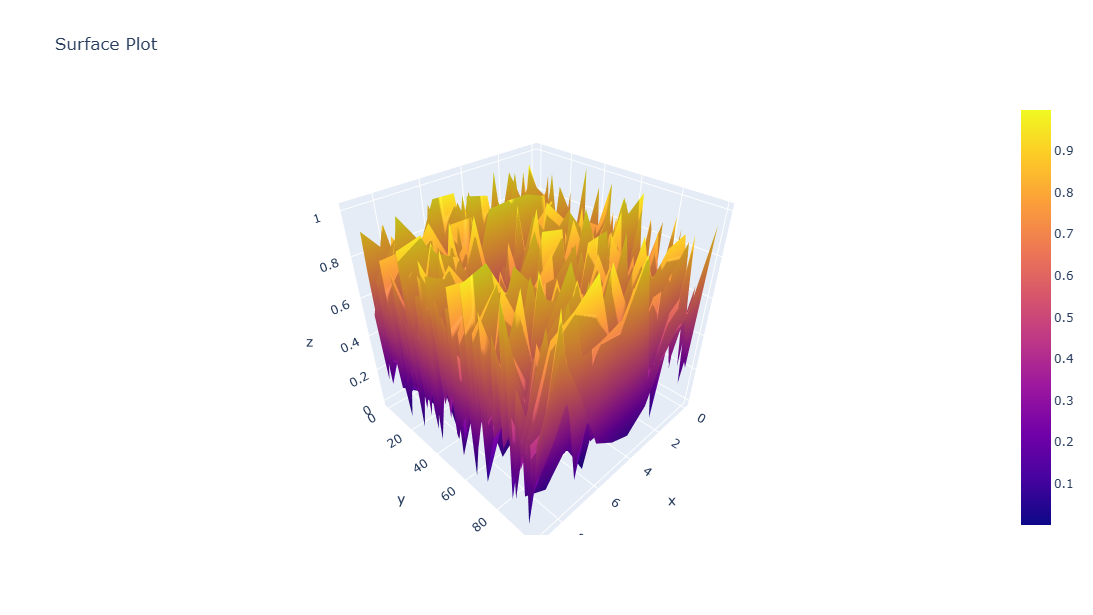

In [10]:
## creating user interface

print("================================================")
print("Select Number of option to select ")
print("1 . Complete Graph")
print("2. Specfic Columns Graph")    
print("------------------------------------------------")

# taking input from user and storing it in ch variable
ch=int(input("Enter your choice: "))
print("------------------------------------------------")
      
# calling graphOptionShow function and passing ch vorioble ds argument
graphOptionShow(ch)

# 